--- Updated Correlation Analysis ---
Pearson Correlation (r): -0.405
P-value: 0.045


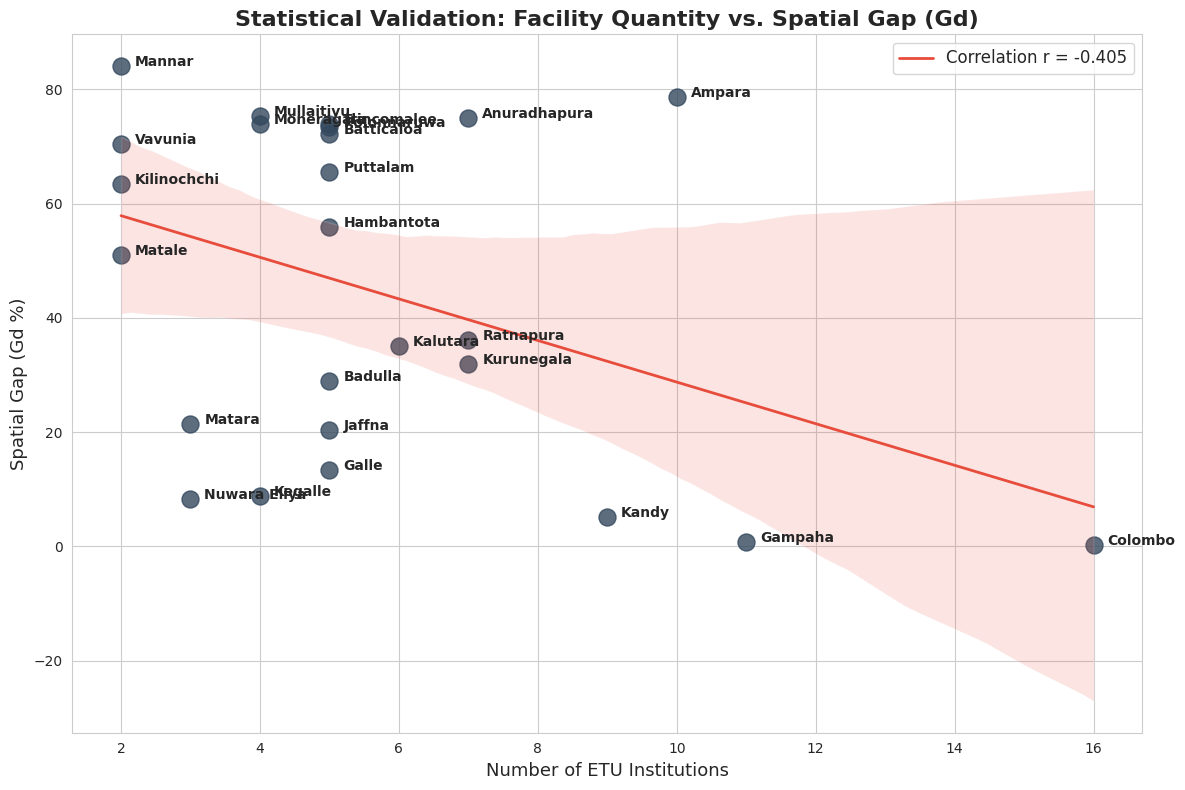

In [3]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Research_Phase2_1.csv')

# 2. CLEANING STEP (The Fix for 'nan')
# This removes any rows where ETU Institutions or Gd might be empty
df = df.dropna(subset=['ETU Institutions', 'Gd'])

# This forces the columns to be numeric (just in case they are seen as text)
df['ETU Institutions'] = pd.to_numeric(df['ETU Institutions'], errors='coerce')
df['Gd'] = pd.to_numeric(df['Gd'], errors='coerce')

# Drop any rows that failed the numeric conversion
df = df.dropna(subset=['ETU Institutions', 'Gd'])

# 3. Calculate Pearson Correlation
r, p = stats.pearsonr(df['ETU Institutions'], df['Gd'])

print(f"--- Updated Correlation Analysis ---")
print(f"Pearson Correlation (r): {r:.3f}")
print(f"P-value: {p:.3f}")

# 4. Create the Validation Plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.regplot(data=df, x='ETU Institutions', y='Gd',
            scatter_kws={'s':150, 'color':'#34495e', 'alpha':0.8},
            line_kws={'color':'#e74c3c', 'linewidth':2, 'label':f'Correlation r = {r:.3f}'})

for i, row in df.iterrows():
    plt.text(row['ETU Institutions'] + 0.2, row['Gd'],
             row['District'], fontsize=10, weight='semibold')

plt.title('Statistical Validation: Facility Quantity vs. Spatial Gap (Gd)', fontsize=16, fontweight='bold')
plt.xlabel('Number of ETU Institutions', fontsize=13)
plt.ylabel('Spatial Gap (Gd %)', fontsize=13)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

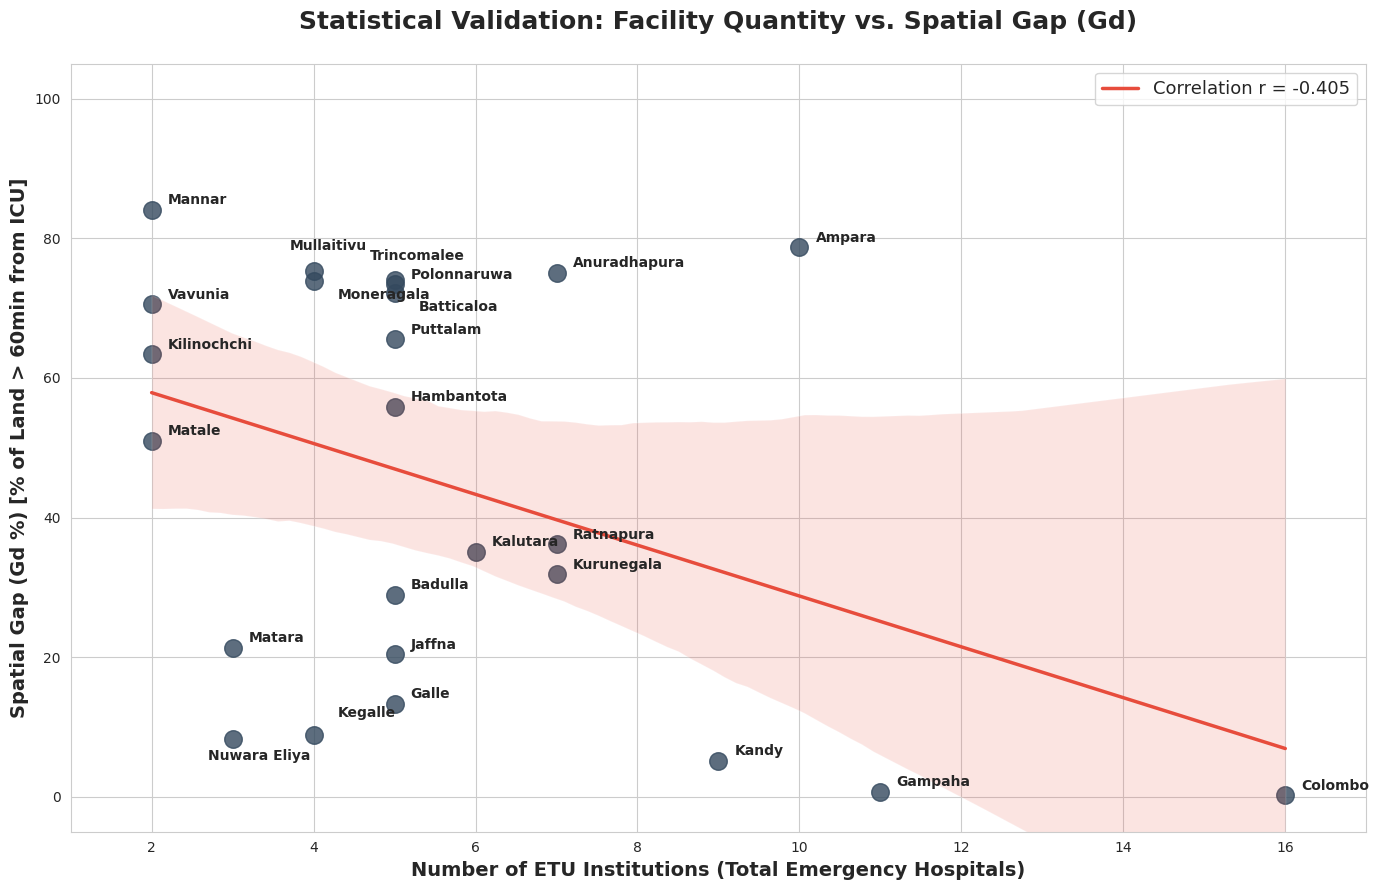

In [4]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your updated data (assumes columns: 'District', 'ETU Institutions', 'Gd')
df = pd.read_csv('Research_Phase2_1.csv')

# 2. Re-calculate Correlation (to ensure the numbers in the legend are right)
# Cleaning step from before just in case
df = df.dropna(subset=['ETU Institutions', 'Gd'])
df['ETU Institutions'] = pd.to_numeric(df['ETU Institutions'], errors='coerce')
df['Gd'] = pd.to_numeric(df['Gd'], errors='coerce')
df = df.dropna(subset=['ETU Institutions', 'Gd'])

r, p = stats.pearsonr(df['ETU Institutions'], df['Gd'])

# 3. Create the Validation Plot
plt.figure(figsize=(14, 9)) # Slightly wider for better label spacing
sns.set_style("whitegrid")

# Regression plot: ETU Institutions vs Gd
sns.regplot(data=df, x='ETU Institutions', y='Gd',
            scatter_kws={'s':160, 'color':'#34495e', 'alpha':0.8},
            line_kws={'color':'#e74c3c', 'linewidth':2.5, 'label':f'Correlation r = {r:.3f}'})

# 4. FIXED LABEL LOGIC (The Manual Nudges for your overlapping pairs)
for i, row in df.iterrows():
    name = row['District']
    x = row['ETU Institutions']
    y = row['Gd']

    # Default offsets (Right and slightly Up)
    dx, dy = 0.2, 0.8

    # --- PAIR 1: Nuwara Eliya & Kegalle (Bottom-Left) ---
    if name == 'Nuwara Eliya':
        dx, dy = -0.3, -3.0    # Move DOWN and LEFT
    if name == 'Kegalle':
        dx, dy = 0.3, 2.5      # Move UP and RIGHT

    # --- PAIR 2: Mullaitivu & Moneragala (Top-Left) ---
    if name == 'Mullaitivu':
        dx, dy = -0.3, 3.0     # Move UP and LEFT
    if name == 'Moneragala':
        dx, dy = 0.3, -2.5     # Move DOWN and RIGHT

    # --- PAIR 3: Trincomalee & Batticaloa (Top-Right) ---
    if name == 'Trincomalee':
        dx, dy = -0.3, 3.0     # Move UP and LEFT
    if name == 'Batticaloa':
        dx, dy = 0.3, -2.5     # Move DOWN and RIGHT

    # Add the text label with the calculated offset
    plt.text(x + dx, y + dy, name, fontsize=10, fontweight='bold', zorder=10)

# 5. Final Axes Formatting
plt.title('Statistical Validation: Facility Quantity vs. Spatial Gap (Gd)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Number of ETU Institutions (Total Emergency Hospitals)', fontsize=14, fontweight='bold')
plt.ylabel('Spatial Gap (Gd %) [% of Land > 60min from ICU]', fontsize=14, fontweight='bold')
plt.legend(fontsize=13, loc='upper right')

# Set clean limits
plt.xlim(df['ETU Institutions'].min() - 1, df['ETU Institutions'].max() + 1)
plt.ylim(-5, 105)

# Save for your paper (300 DPI for high-quality printing)
plt.tight_layout()
plt.savefig('Final_Hospital_Quantity_Correlation.png', dpi=300)
plt.show()